# <font color = 'indianred'>**Multilabel Classification of StackExchange Dataset using GEMMA** </font>

**Objective:**<br>
Demonstrate inference and evaluation of an Instruction Gemma-2-2B-it model for a multilabel text classification task on the StackExchange dataset using vLLM.
The notebook shows how to: <br>

1. Perform guided (constrained) decoding via JSON schema enforcement to produce structured label outputs.<br>
2. Generate predictions with vLLM’s high-performance inference engine.<br>
3. Evaluate results using multilabel metrics (macro F1) and visualize performance through confusion matrices.<br>
4. Log validation and test performance to Weights & Biases (WandB) for experiment tracking.<br>

**Plan**

1. Set Environment
2. Load Dataset
3. Download Model and setup vLLM
4. Setup WandB
5. Validation
6. Performance on Test Set





















# <font color = 'indianred'> **1. Setting up the Environment** </font>



In [1]:
if 'google.colab' in str(get_ipython()):
    !pip install numpy -U -qq
    !pip install transformers evaluate wandb datasets accelerate trl peft bitsandbytes -U -qq
    !pip install vllm==0.11.2
    !pip uninstall tensorflow -y -qq


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 75.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.5 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

^C


 <Font size = 5 color = 'indianred'>**Restart the session before moving onto next cell**
> Runtime- Restart Session

<font color = 'indianred'> *Load Libraries* </font>

In [1]:
import os
os.environ['VLLM_USE_V1'] = '1' # this should be done befre any other import

import torch
import torch.nn as nn
from vllm import LLM, SamplingParams
from vllm.lora.request import LoRARequest
from vllm.sampling_params import GuidedDecodingParams

In [2]:
# standard pythgion libraries
from pathlib import Path

from typing import Dict, List, Union, Optional, Tuple
from tqdm import tqdm
import json
import os
import sys

# Data Science librraies
import numpy as np
import pandas as pd

from pprint import pprint

# Pytorch
import torch

# Huggingface Librraies
import evaluate
from datasets import load_dataset

from huggingface_hub import login

# Logging and secrets
import wandb
from google.colab import userdata
from huggingface_hub import login, HfApi, create_repo

In [3]:
# standard pythgion libraries
from pathlib import Path

from typing import Dict, List, Union, Optional, Tuple
from tqdm import tqdm
import json
import os
import sys

# Data Science librraies
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from pprint import pprint

# Pytorch
import torch

# Huggingface Librraies
import evaluate
from datasets import load_dataset

from huggingface_hub import login

# Logging and secrets
import wandb
from google.colab import userdata
from huggingface_hub import login, HfApi, create_repo

In [4]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/nvidia_cutlass_dsl/python_packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython',
 '/tmp/tmpzifb_lyu']

In [5]:
# If running on Google Colab, use Google Drive as storage
# CHANGE FOLDERS TO WHERE YOU WANT TO SAVE DATA AND MODELS

if 'google.colab' in str(get_ipython()):
    from google.colab import drive  # Import Google Drive mounting utility
    drive.mount('/content/drive')  # Mount Google Drive

    # Set base folder path for storing data on Google Drive
    data_folder= Path('/content/drive/MyDrive')
    project_folder = Path('/content/drive/MyDrive')
    base_folder = Path('/content/drive/MyDrive')

# If running locally, specify a different path
else:
    # Set base folder path for storing data on local machine
    data_folder= Path('/home/harpreet/Insync/google_drive_shaannoor/data')
    project_folder= Path('/home/harpreet/Insync/google_drive_shaannoor/teaching_fall_2025/LLM_Fall_2025/')

Mounted at /content/drive


In [6]:
util_folder = project_folder/'shared_utils'

In [7]:
sys.path.append(str(util_folder))

In [8]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/nvidia_cutlass_dsl/python_packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython',
 '/tmp/tmpzifb_lyu',
 '/content/drive/MyDrive/shared_utils']

In [9]:
from shared_utils import free_gpu_memory,  multilabel_evaluation

In [10]:
wandb_api_key = userdata.get('WANDB_API_KEY')
hf_token = userdata.get('HF_TOKEN')

In [11]:
if hf_token:
    # Log in to Hugging Face
    login(token=hf_token)
    print("Successfully logged in to Hugging Face!")
else:
    print("Hugging Face token not found in notebook secrets.")

Successfully logged in to Hugging Face!


In [12]:
if wandb_api_key:
  wandb.login(key=wandb_api_key)
  print("Successfully logged in to WANDB!")
else:
    print("WANDB key not found in notebook secrets.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: younes-hoseini67 (younes-hoseini67-university-of-texas-at-dallas) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Successfully logged in to WANDB!


In [13]:
kaggle_api = base_folder/'.kaggle'
import os
if 'google.colab' in str(get_ipython()):
    os.environ['KAGGLE_CONFIG_DIR'] = "/content/drive/MyDrive/ADL_MSBA_UTD/.kaggle/"
if 'google.colab' in str(get_ipython()):
    !chmod 600 /content/drive/MyDrive/.kaggle/kaggle.json
if 'google.colab' in str(get_ipython()):
    ! ls -la  /content/drive/MyDrive/.kaggle/kaggle.json

-rw------- 1 root root 67 Oct 27 23:03 /content/drive/MyDrive/.kaggle/kaggle.json


# <font color = 'indianred'> **2. Load Data set**
    


In [14]:
val_split = load_dataset('sayedyounes/stack_multilabel_subset_chat', split = 'valid')
test_split = load_dataset('sayedyounes/stack_multilabel_subset_chat', split = 'test')
print()
print(val_split[0])

README.md:   0%|          | 0.00/544 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/193k [00:00<?, ?B/s]

data/valid-00000-of-00001.parquet:   0%|          | 0.00/150k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/151k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/1545 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1545 [00:00<?, ? examples/s]


{'messages': [{'content': "Classify the TEXT by selecting all applicable labels from the following list: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust'].\n\nTEXT: @ChrisChristie You have no Police credentials-You were a litigator. Nothing more-No Experience.#Sad #TrumpPuppet #Felon #bully #jersey4sale", 'role': 'user'}, {'content': '["anger", "disgust", "sadness"]', 'role': 'assistant'}]}


#  <font color = 'indianred'> **3. Download Model and setup vLLM**

In [15]:
torch.cuda.empty_cache()
BASE_MODEL = "google/gemma-2-2b-it"
LORA_ADAPTER = "sayedyounes/stack_exc_multilabel_instr_lm_head"

In [16]:
llm = LLM(
    model=BASE_MODEL,
    dtype=torch.bfloat16,
    trust_remote_code=True,
    quantization="bitsandbytes",
    enable_lora=True,
    max_lora_rank=128,
    gpu_memory_utilization=0.8,
    guided_decoding_backend="outlines",
)

INFO 12-15 01:30:10 [utils.py:253] non-default args: {'trust_remote_code': True, 'dtype': torch.bfloat16, 'gpu_memory_utilization': 0.8, 'disable_log_stats': True, 'quantization': 'bitsandbytes', 'enable_lora': True, 'max_lora_rank': 128, 'guided_decoding_backend': 'outlines', 'model': 'google/gemma-2-2b-it'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

INFO 12-15 01:30:30 [model.py:631] Resolved architecture: Gemma2ForCausalLM
INFO 12-15 01:30:30 [model.py:1745] Using max model len 8192
INFO 12-15 01:30:30 [scheduler.py:216] Chunked prefill is enabled with max_num_batched_tokens=8192.


tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

WARNING 12-15 01:30:36 [system_utils.py:103] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 12-15 01:33:02 [llm.py:352] Supported tasks: ['generate']


In [17]:
lora_request = LoRARequest(
    lora_name="stack_classifier",
    lora_int_id=1,
    lora_path=LORA_ADAPTER
)

class_names = ['anger', 'anticipation', 'disgust', 'fear', 'joy',
               'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

array_schema = {
    "type": "array",
    "items": {
        "type": "string",
        "enum": class_names
    },
    "minItems": 0,
    "maxItems": 11
}

guided_decoding = GuidedDecodingParams(
    json=array_schema,
    backend="outlines"
)

sampling_params = SamplingParams(
    temperature=0,
    max_tokens=100,
    guided_decoding=guided_decoding,
)

/tmp/ipython-input-2605736892.py:25: DeprecationWarning: guided_decoding is deprecated. This will be removed in v0.12.0 or v1.0.0, which ever is soonest. Please use structured_outputs instead.
  sampling_params = SamplingParams(


# <font color = 'indianred'> **4. Setup WandB**</font>

In [18]:

%env WANDB_PROJECT = emotion-detection

run = wandb.init(

    project="emotion-detection",
    #entity="mxg230038-the-university-of-texas-at-dallas",
    name="partC_inference_instruction_vllm",
    tags=["part-c", "inference", "instruction", "vllm"],
)


env: WANDB_PROJECT=emotion-detection


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


#<font color = 'indianred'> **5. Utility Functions**

In [19]:
def generate_predictions_batch(prompts: List[str],
                               llm: LLM,
                               sampling_params: SamplingParams,
                               lora_request: LoRARequest,
                               batch_size: int = 64) -> List[List[str]]:
    """
    Generate predictions for a list of prompts using vLLM batch inference.

    Args:
        prompts: List of input prompts
        llm: vLLM model instance
        sampling_params: Sampling parameters for generation
        lora_request: LoRA adapter request
        batch_size: Batch size for inference

    Returns:
        List of predicted labels (as lists of strings)
    """
    predictions = []

    for i in tqdm(range(0, len(prompts), batch_size), desc="Generating predictions"):
        batch = prompts[i:i+batch_size]

        outputs = llm.generate(
            batch,
            sampling_params,
            lora_request=lora_request
        )

        for output in outputs:
            pred = json.loads(output.outputs[0].text)
            predictions.append(pred)


    print(f"Processed {len(predictions)}/{len(prompts)} prompts")
    return predictions

In [20]:
def parse_label_string(label_str: str) -> List[str]:
    """Parse label string to list of labels."""
    try:
        return json.loads(label_str.strip())
    except:
        return []

In [21]:
f1 = evaluate.load('f1','multilabel')
def compute_metrics( labels, preds):
  f1_macro = f1.compute(predictions=preds, references=labels, average='macro')
  return {'f1_macro':f1_macro['f1'],}

In [22]:
def evaluate_multilabel_predictions(true_labels: Union[List[str], List[List[str]]],
                                     predictions: List[List[str]],
                                     class_names: List[str],
                                     split_name: str = "valid",
                                     log_to_wandb: bool = True,
                                     show_confusion_matrix: bool = True) -> Dict:
    """
    Evaluate multilabel predictions and optionally log to wandb.

    Args:
        true_labels: List of label strings OR list of label lists
        predictions: List of predicted label lists
        class_names: List of all possible class names
        split_name: Name of the split (for wandb logging)
        log_to_wandb: Whether to log metrics to wandb
        show_confusion_matrix: Whether to display confusion matrix

    Returns:
        Dictionary containing evaluation metrics
    """
    # Parse true labels only if they are strings
    if len(true_labels) > 0 and isinstance(true_labels[0], str):
        parsed_labels = [parse_label_string(label) for label in true_labels]
        print(f"Parsed string labels to lists")
    else:
        parsed_labels = true_labels
        print(f"Labels already in list format")

    # Initialize MultiLabelBinarizer
    mlb = MultiLabelBinarizer(classes=class_names)
    mlb.fit([class_names])  # Fit with all possible classes

    # Transform to binary format
    labels_binary = mlb.transform(parsed_labels)
    predictions_binary = mlb.transform(predictions)

    # Print samples and shapes
    print(f"\n{'='*60}")
    print(f"{split_name.upper()} SET EVALUATION")
    print(f"{'='*60}")
    print(f"Sample true labels: {parsed_labels[:3]}")
    print(f"Sample predictions: {predictions[:3]}")
    print(f"\nBinary shapes:")
    print(f"  Labels:      {labels_binary.shape}")
    print(f"  Predictions: {predictions_binary.shape}")

    # Compute metrics
    metrics = compute_metrics(labels_binary, predictions_binary)
    print(f"\nMetrics:")
    print(f"  F1 Macro: {metrics['f1_macro']:.4f}")

    # Log to wandb
    if log_to_wandb:
        wandb.log({f"{split_name}_f1_macro": metrics["f1_macro"]})
        print(f"  ✓ Logged to wandb")

    # Display confusion matrix
    if show_confusion_matrix:
        print(f"\nConfusion Matrix:")
        multilabel_evaluation(
            y_true=labels_binary,
            y_pred=predictions_binary,
            class_names=class_names,
            figsize=(12, 8)
        )

    return metrics

#<font color = 'indianred'> **6. Performance on Validation Set**

<font color = 'indianred'> *Evaluate model on Validation Set* </font>


In [23]:
class_names

['anger',
 'anticipation',
 'disgust',
 'fear',
 'joy',
 'love',
 'optimism',
 'pessimism',
 'sadness',
 'surprise',
 'trust']

In [24]:
tokenizer = llm.get_tokenizer()

In [25]:
tokenizer.chat_template

"{{ bos_token }}{% if messages[0]['role'] == 'system' %}{{ raise_exception('System role not supported') }}{% endif %}{% for message in messages %}{% if (message['role'] == 'user') != (loop.index0 % 2 == 0) %}{{ raise_exception('Conversation roles must alternate user/assistant/user/assistant/...') }}{% endif %}{% if (message['role'] == 'assistant') %}{% set role = 'model' %}{% else %}{% set role = message['role'] %}{% endif %}{{ '<start_of_turn>' + role + '\n' + message['content'] | trim + '<end_of_turn>\n' }}{% endfor %}{% if add_generation_prompt %}{{'<start_of_turn>model\n'}}{% endif %}"

In [26]:
# Save template to file
with open('template.jinja', 'w') as f:
    f.write(tokenizer.chat_template)
# Format it
!djlint template.jinja --reformat --quiet
# Read it back
with open('template.jinja', 'r') as f:
    print(f.read())

/bin/bash: line 1: djlint: command not found
{{ bos_token }}{% if messages[0]['role'] == 'system' %}{{ raise_exception('System role not supported') }}{% endif %}{% for message in messages %}{% if (message['role'] == 'user') != (loop.index0 % 2 == 0) %}{{ raise_exception('Conversation roles must alternate user/assistant/user/assistant/...') }}{% endif %}{% if (message['role'] == 'assistant') %}{% set role = 'model' %}{% else %}{% set role = message['role'] %}{% endif %}{{ '<start_of_turn>' + role + '
' + message['content'] | trim + '<end_of_turn>
' }}{% endfor %}{% if add_generation_prompt %}{{'<start_of_turn>model
'}}{% endif %}


In [27]:
val_prompts = [
    tokenizer.apply_chat_template(
        [{"role": "user", "content": example["messages"][0]["content"]}],
        tokenize=False,
        add_generation_prompt=True
    )
    for example in val_split
]

In [28]:
print(val_prompts[0])

<bos><start_of_turn>user
Classify the TEXT by selecting all applicable labels from the following list: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust'].

TEXT: @ChrisChristie You have no Police credentials-You were a litigator. Nothing more-No Experience.#Sad #TrumpPuppet #Felon #bully #jersey4sale<end_of_turn>
<start_of_turn>model



In [29]:
val_predictions = generate_predictions_batch(
    prompts=val_prompts,
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=64
)

Generating predictions:   0%|          | 0/25 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/64 [00:00<?, ?it/s]

WARNING 12-15 01:34:50 [processor.py:246] vLLM has deprecated support for supporting different tokenizers for different LoRAs. By default, vLLM uses base model's tokenizer. If you are using a LoRA with its own tokenizer, consider specifying `--tokenizer [lora_path]` to use the LoRA tokenizer.


Processed prompts:   0%|          | 0/64 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions:   4%|▍         | 1/25 [00:30<12:22, 30.96s/it]

...

Generating predictions:  96%|█████████▌| 24/25 [00:44<00:00,  1.74it/s]

Adding requests:   0%|          | 0/9 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/9 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 25/25 [00:44<00:00,  1.77s/it]

Processed 1545/1545 prompts


In [30]:
val_predictions[0:5]

[['anger', 'disgust', 'sadness'],
 ['anticipation', 'joy', 'optimism'],
 ['joy', 'optimism'],
 ['joy', 'love', 'optimism'],
 ['anger', 'disgust', 'fear', 'sadness']]

In [31]:
# Extract ground truth labels
val_labels = [
    json.loads(example["messages"][1]["content"])  # Assistant's message
    for example in val_split
]

val_labels[0:5]

[['anger', 'disgust', 'sadness'],
 ['anticipation', 'joy', 'optimism'],
 ['anticipation', 'disgust', 'joy'],
 ['joy', 'love', 'optimism'],
 ['fear', 'sadness']]

Labels already in list format

VALID SET EVALUATION
Sample true labels: [['anger', 'disgust', 'sadness'], ['anticipation', 'joy', 'optimism'], ['anticipation', 'disgust', 'joy']]
Sample predictions: [['anger', 'disgust', 'sadness'], ['anticipation', 'joy', 'optimism'], ['joy', 'optimism']]

Binary shapes:
  Labels:      (1545, 11)
  Predictions: (1545, 11)

Metrics:
  F1 Macro: 0.5253
  ✓ Logged to wandb

Confusion Matrix:


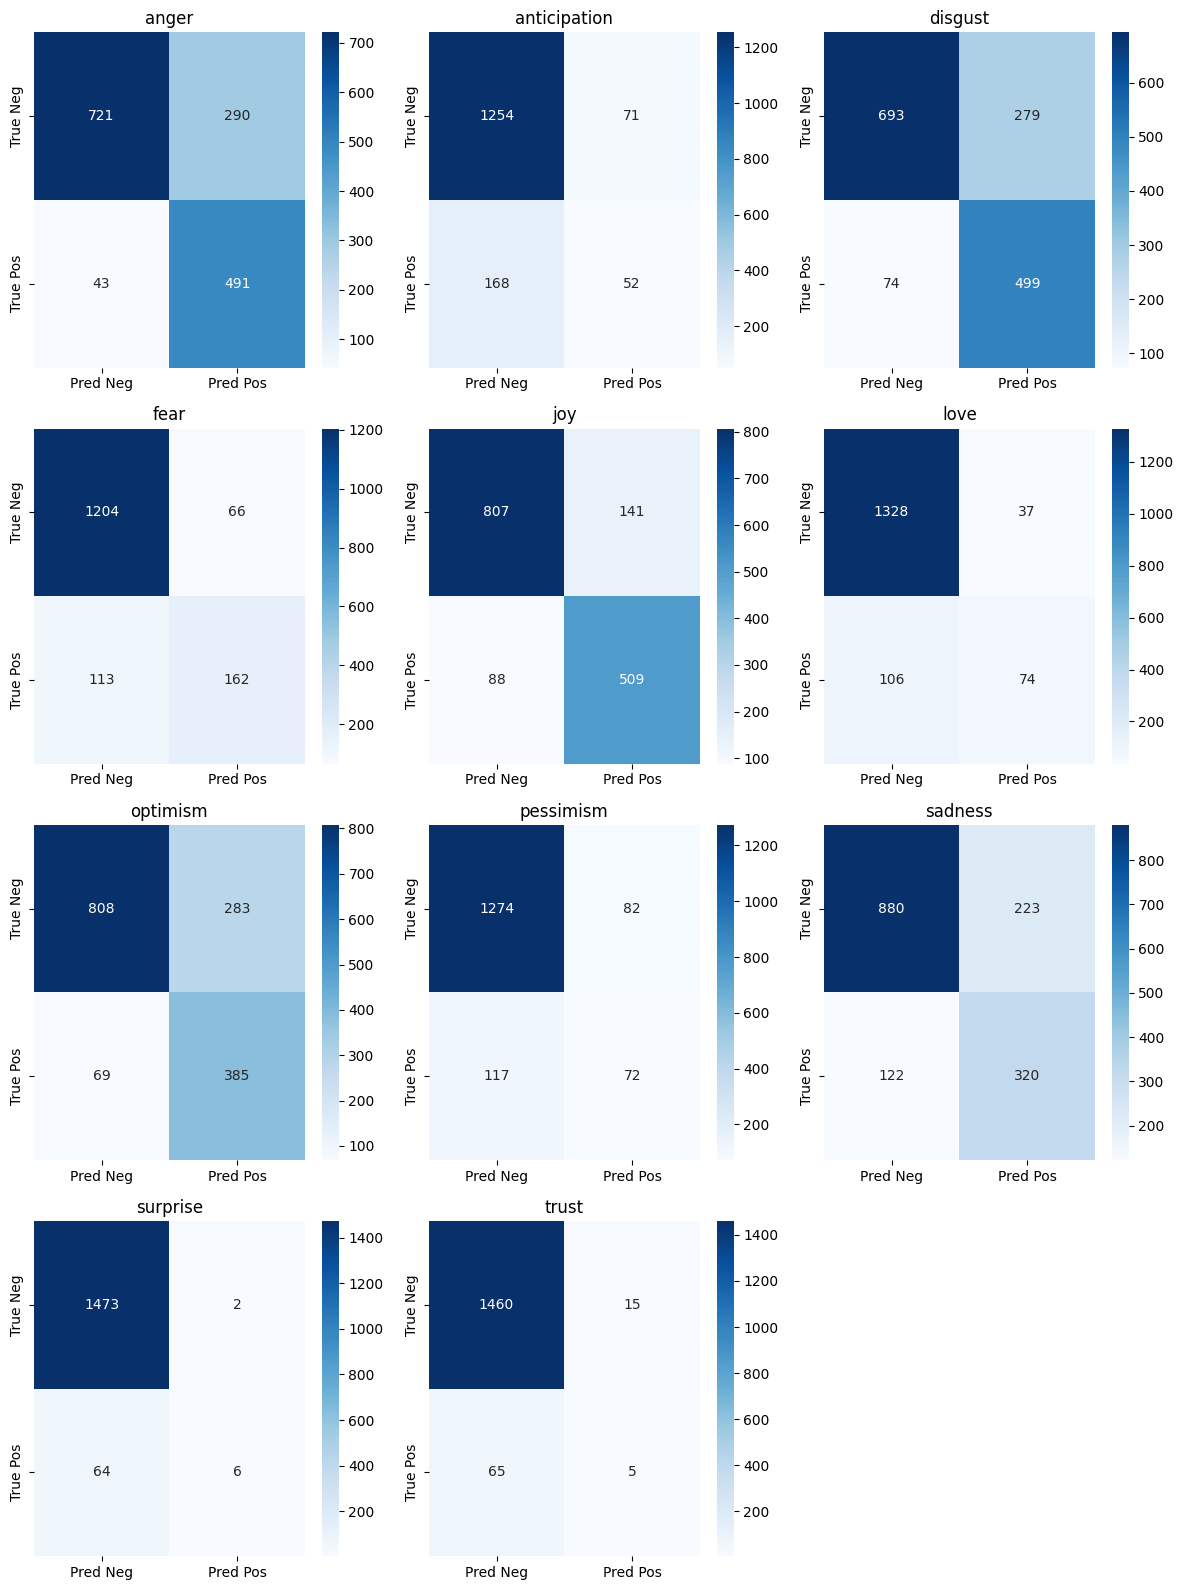

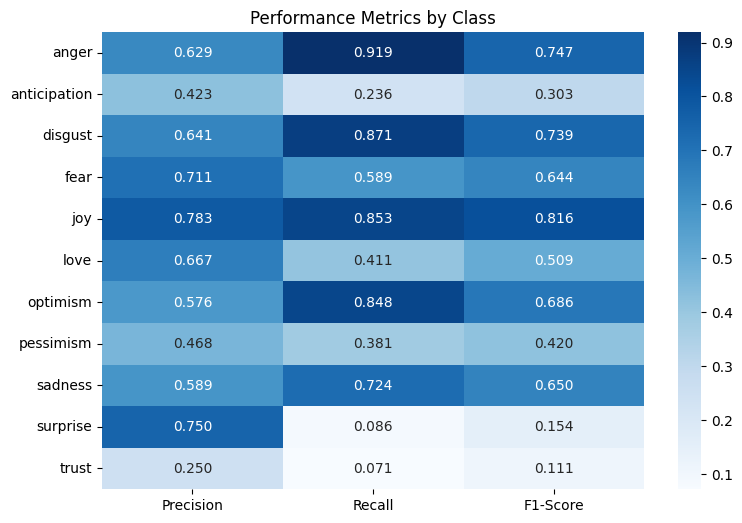

<Figure size 1200x533.333 with 0 Axes>

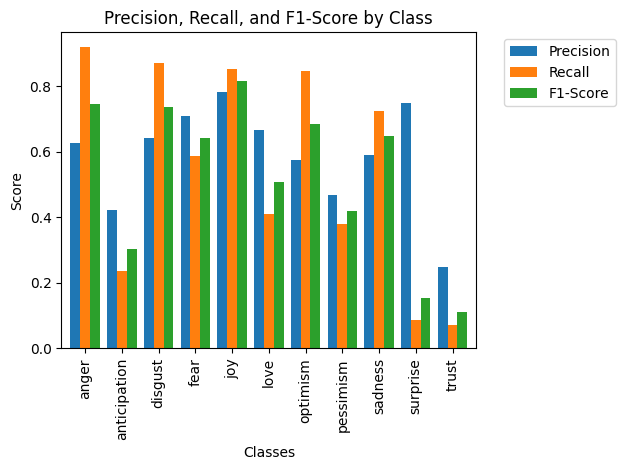

In [32]:
# Evaluate
valid_metrics = evaluate_multilabel_predictions(
    true_labels=val_labels,
    predictions=val_predictions,
    class_names=class_names,
    split_name="valid",
    log_to_wandb=True,
    show_confusion_matrix=True
)

#  <font color = 'indianred'> **7. Performance on Test Set** </font>
For test set evaluation, we will perfrom following steps:

In [33]:
test_prompts = [
    tokenizer.apply_chat_template(
        [{"role": "user", "content": example["messages"][0]["content"]}],
        tokenize=False,
        add_generation_prompt=True
    )
    for example in test_split
]

In [34]:
# Generate predictions
test_predictions = generate_predictions_batch(
    prompts=test_prompts,
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=128
)

Generating predictions:   0%|          | 0/13 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/128 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/128 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions:   8%|▊         | 1/13 [00:00<00:10,  1.20it/s]

Adding requests:   0%|          | 0/128 [00:00<?, ?it/s]

...

Generating predictions:  92%|█████████▏| 12/13 [00:09<00:00,  1.35it/s]

Adding requests:   0%|          | 0/9 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/9 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 13/13 [00:09<00:00,  1.38it/s]

Processed 1545/1545 prompts


In [35]:
# Extract ground truth labels
test_labels = [
    json.loads(example["messages"][1]["content"])
    for example in test_split
]

test_labels[0:5]

[['joy', 'love'],
 ['joy'],
 ['joy', 'love', 'optimism'],
 ['anticipation', 'fear', 'sadness'],
 ['pessimism', 'sadness']]

Labels already in list format

TEST SET EVALUATION
Sample true labels: [['joy', 'love'], ['joy'], ['joy', 'love', 'optimism']]
Sample predictions: [['joy', 'love', 'optimism'], ['joy', 'optimism'], ['joy', 'love', 'optimism']]

Binary shapes:
  Labels:      (1545, 11)
  Predictions: (1545, 11)

Metrics:
  F1 Macro: 0.5451
  ✓ Logged to wandb

Confusion Matrix:


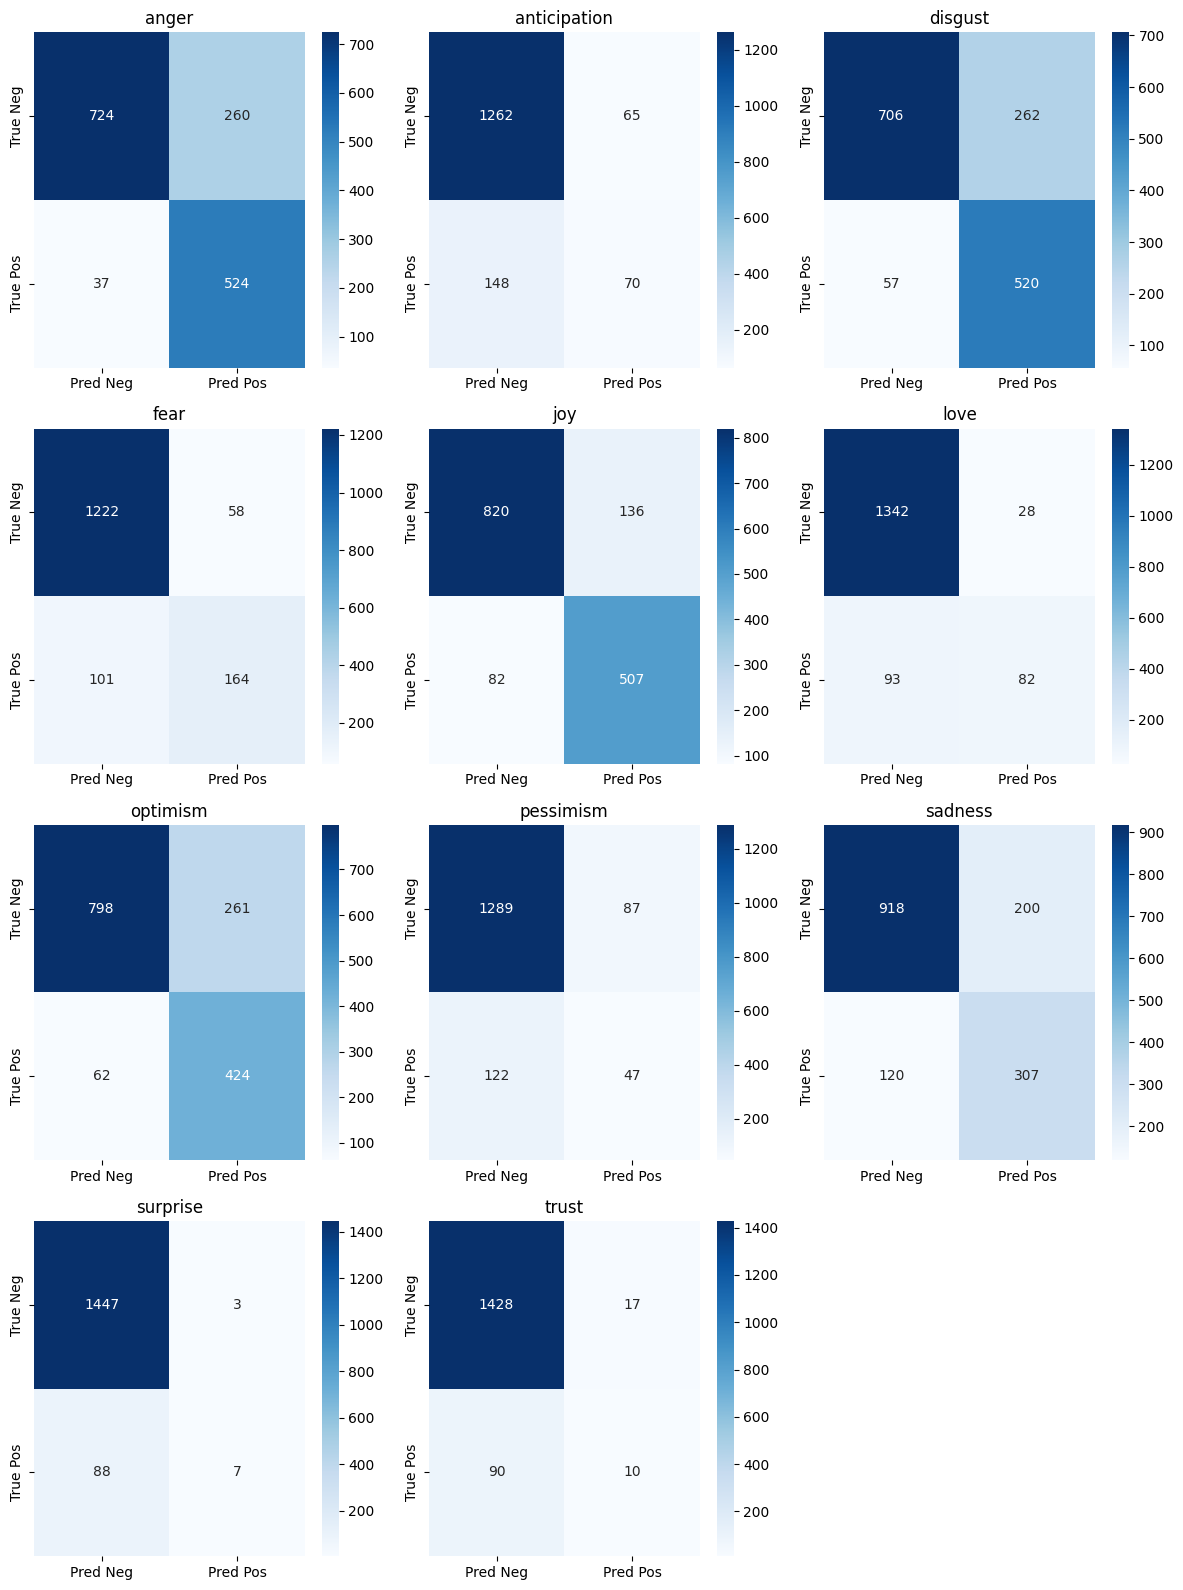

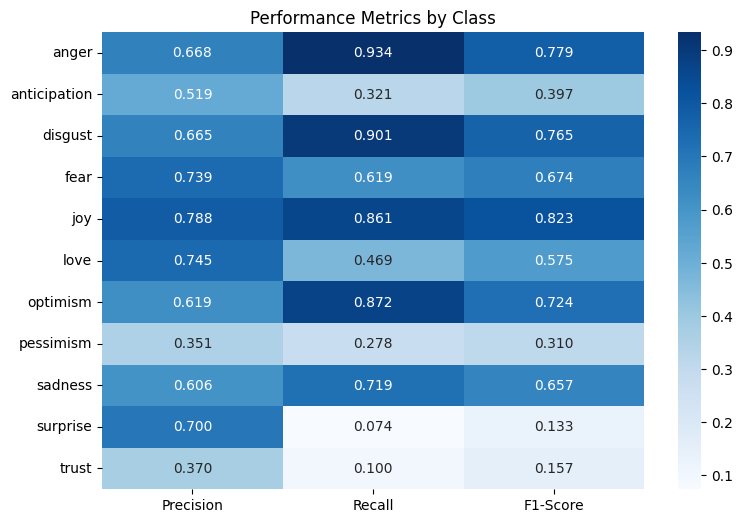

<Figure size 1200x533.333 with 0 Axes>

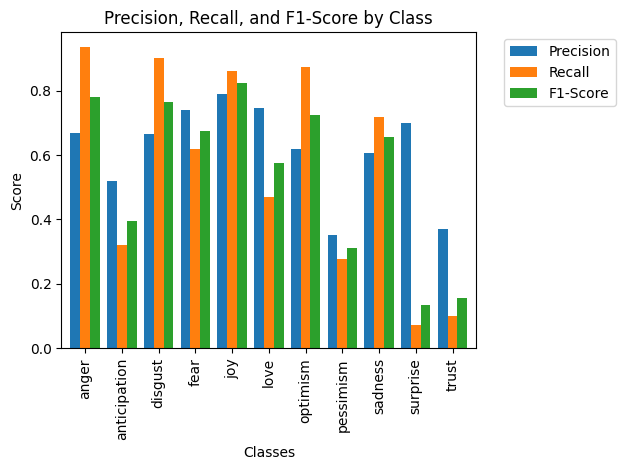

In [36]:
# Evaluate
test_metrics = evaluate_multilabel_predictions(
    true_labels=test_labels,
    predictions=test_predictions,
    class_names=class_names,
    split_name="test",
    log_to_wandb=True,
    show_confusion_matrix=True
)

In [37]:
wandb.finish()

test_f1_macro,▁
valid_f1_macro,▁
test_f1_macro,0.54506
valid_f1_macro,0.52533


# <font color = 'indianred'> **8. Inference** </font>

<font color = 'indianred'> *Demonstrate inference on a single text input* </font>


In [38]:
def create_chat_prompt_for_single_text(text: str, tokenizer) -> str:
    user_message = f"""Classify the TEXT by selecting all applicable labels from the following list: {class_names}.

TEXT: {text}"""


    # Format as chat message
    messages = [{"role": "user", "content": user_message}]

    # Apply chat template
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    return prompt

## <font color = 'indianred'> Example 1: Single text *inference* </font>


In [39]:
#Example 1: Single text inference
text_1 = "I am so excited and happy about the new project! Can't wait to get started!"

# Create chat-formatted prompt
prompt_1 = create_chat_prompt_for_single_text(text_1, tokenizer)

# Predict using existing function (pass as single-item list)
prediction_1 = generate_predictions_batch(
    prompts=[prompt_1],  # Single prompt as a list
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=1
)

print("\nInput Text:")
pprint(text_1)
print("\n" + "="*60)
print("Formatted prompt:")
pprint(prompt_1)
print("\n" + "="*60)
print(f"Predicted Labels: {prediction_1[0]}")  # Get first (only) prediction

Generating predictions:   0%|          | 0/1 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 1/1 [00:00<00:00,  8.34it/s]

Processed 1/1 prompts

Input Text:
"I am so excited and happy about the new project! Can't wait to get started!"

Formatted prompt:
('<bos><start_of_turn>user\n'
 'Classify the TEXT by selecting all applicable labels from the following '
 "list: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', "
 "'optimism', 'pessimism', 'sadness', 'surprise', 'trust'].\n"
 '\n'
 "TEXT: I am so excited and happy about the new project! Can't wait to get "
 'started!<end_of_turn>\n'
 '<start_of_turn>model\n')

Predicted Labels: ['joy', 'optimism']


## <font color = 'indianred'> Example 2: Multiple custom texts at once </font>


In [40]:
#Example 2: Multiple custom texts at once
custom_texts = [
    "I'm feeling really anxious about the exam tomorrow",
    "What a beautiful day! Everything is going perfectly!",
    "I can't believe they did that. I'm so angry right now.",
    "Worried about the future but trying to stay optimistic"
]
# Create chat-formatted prompts
custom_prompts = [create_chat_prompt_for_single_text(text, tokenizer) for text in custom_texts]

# Predict using existing function
custom_predictions = generate_predictions_batch(
    prompts=custom_prompts,
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=64
)

# Display results
print("Batch Inference Results:")
print("="*60)
for text, pred in zip(custom_texts, custom_predictions):
    print(f"\nText: {text}")
    print(f"Predicted Labels: {pred}")
    print("-"*60)

Generating predictions:   0%|          | 0/1 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/4 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/4 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 1/1 [00:00<00:00,  3.52it/s]

Processed 4/4 prompts
Batch Inference Results:

Text: I'm feeling really anxious about the exam tomorrow
Predicted Labels: ['fear', 'pessimism', 'sadness']
------------------------------------------------------------

Text: What a beautiful day! Everything is going perfectly!
Predicted Labels: ['joy', 'optimism']
------------------------------------------------------------

Text: I can't believe they did that. I'm so angry right now.
Predicted Labels: ['anger', 'disgust']
------------------------------------------------------------

Text: Worried about the future but trying to stay optimistic
Predicted Labels: ['fear', 'optimism', 'pessimism', 'sadness']
------------------------------------------------------------
